Merge positive and negative over time.


=== Negative System DataFrame ===
   time_ps  angle_chain1  angle_chain2  angle_chain3  angle_chain4  \
0      0.0        83.106        80.869        80.525        66.069   
1     50.0        87.139        80.672        81.339        66.384   
2    100.0        87.545        83.573        81.322        68.559   
3    150.0        89.938        78.724        80.092        73.211   
4    200.0        79.247        81.629        80.806        72.017   

   angle_chain5  angle_chain6  angle_chain7  angle_chain8  angle_chain9  \
0        60.402        73.656        80.767        71.226        88.783   
1        62.676        75.495        75.945        70.651        89.789   
2        60.181        75.981        80.611        69.689        85.506   
3        55.112        71.743        82.268        72.118        84.720   
4        49.179        72.367        75.548        73.479        89.034   

   angle_chain10  angle_chain11  angle_chain12  angle_chain13  angle_chain14  \
0         82.

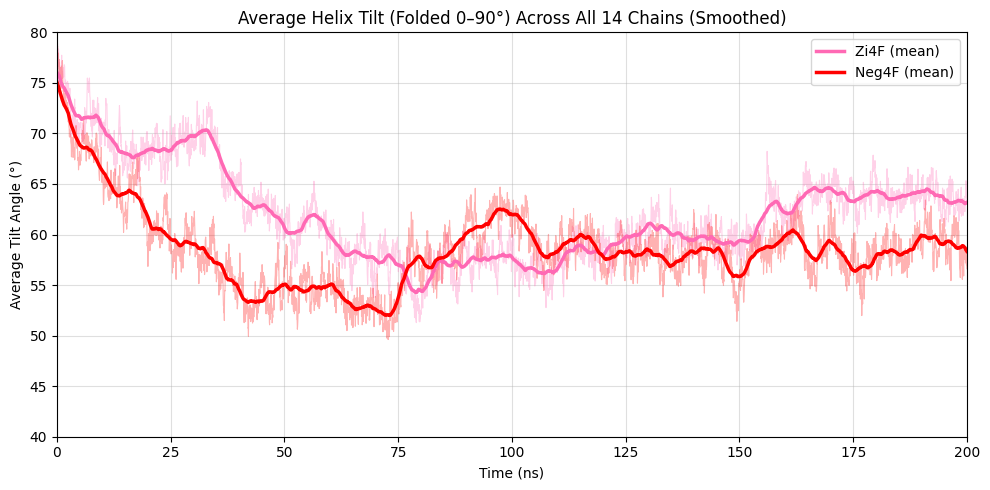

✅ Plot saved to: D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_angle_vs_time_smooth_fixed.pdf

Zi4F(75–200 ns): mean = 60.18°, std = 3.26°
Neg4F (75–200 ns): mean = 58.60°, std = 2.12°


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Paths ===
pos_dir = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\analysis_pos\analysis_positive_200ns"
neg_dir = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\analysis_neg\analysis_negative_200ns"
save_file = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_angle_vs_time_smooth_fixed.pdf"
save_file2 = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_angle_vs_time_smooth_fixed.png"


# === Function to load and fold angles ===
def load_folded_avg(base_dir):
    all_dfs = []        #        # Create an empty list to store one DataFrame per chain (14 chains total)
    for chain in range(1, 15):   # Loop through chain numbers 1 to 14
        
        # Build the full path to the file for this chain
        # Example: base_dir + "chain3_tilt_vsZ.xvg"
        filepath = os.path.join(base_dir, f"chain{chain}_tilt_vsZ.xvg")         #It takes pieces of a file path and joins them correctly,
        
        # Open the .xvg file and read lines.
            # Keep only the lines that:
            #   - do NOT start with '#' (comments)
            #   - do NOT start with '@' (metadata)
            #   - are NOT empty
        with open(filepath) as f:
            lines = [line for line in f if not line.startswith(('#', '@')) and line.strip()]
        
        # Convert each line into a list of numbers (float)
        # Example: "0 45.3" → [0.0, 45.3]
        data_lines = [[float(x) for x in line.split()] for line in lines]
        
        
        # Create a DataFrame with two columns:
        #   - time_ps
        #   - angle_chainX  where X is the chain number
        df = pd.DataFrame(data_lines, columns=["time_ps", f"angle_chain{chain}"])
        #print("Before folding:\n", df.head())
        
        
        # Fold angles above 90 degrees into the 0–90 range
        # If angle <= 90 → keep it
        # If angle > 90 → convert to (180 - angle)
        # Fold 180° → 0–90°
        df[f"angle_chain{chain}"] = df[f"angle_chain{chain}"].apply(lambda a: a if a <= 90 else 180 - a)
        
        
        # Add this chain's DataFrame into the list
        all_dfs.append(df)
    
    
    # Start merging using the first chain's DataFrame
    merged_df = all_dfs[0]
    
    
    
    # Merge all other DataFrames into the first one by time_ps
    for df in all_dfs[1:]:
        # Merge on "time_ps" column
        merged_df = pd.merge(merged_df, df, on="time_ps", how="outer")
    ####################################################################
    #################Check merged DataFrame#############################
    ####################################################################
    #print("\n=== Merged DataFrame (first 5 rows) ===")
    #print(merged_df.head())
    

    ####################################################################
    ####################################################################
    
    # Collect the names of all angle columns (angle_chain1, angle_chain2, ...)
    angle_cols = [c for c in merged_df.columns if c.startswith("angle_chain")]
    
    
    # Average the angle values across all chains
    merged_df["avg_tilt"] = merged_df[angle_cols].mean(axis=1)
    #print(merged_df.head())
    system_name = os.path.basename(base_dir)
    merged_df.to_csv(f"{system_name}_merged.csv", index=False)
    
    
    
    # Return the final DataFrame containing:
    # time_ps, angle_chain1..14, avg_tilt
    return merged_df



# === Load both systems ===
pos_df = load_folded_avg(pos_dir)
neg_df = load_folded_avg(neg_dir)

#print("\n=== Positive System DataFrame ===")
#print(pos_df.head())
print("\n=== Negative System DataFrame ===")
print(neg_df.head())

# === Smooth using rolling mean (edge-safe) ===
#I wanted to smooth over 5 nanoseconds, so I converted that into the number of frames based on the time step between frames.
total_time_ns = 200
n_frames = len(pos_df)
print(f"Total frames: {n_frames}, Total time: {total_time_ns} ns")
smooth_window_ns = 5
window = int((smooth_window_ns / total_time_ns) * n_frames)
print(f"Smoothing window: {window} frames (~{smooth_window_ns} ns)")

pos_df["smooth_tilt"] = pos_df["avg_tilt"].rolling(window, center=True, min_periods=1).mean()
neg_df["smooth_tilt"] = neg_df["avg_tilt"].rolling(window, center=True, min_periods=1).mean()

# === Plot ===
plt.figure(figsize=(10, 5))
plt.plot(pos_df["time_ps"]/1000, pos_df["avg_tilt"], color="#FF69B4", lw=0.8, alpha=0.3)
plt.plot(neg_df["time_ps"]/1000, neg_df["avg_tilt"], color="#ff0000", lw=0.8, alpha=0.3)
plt.plot(pos_df["time_ps"]/1000, pos_df["smooth_tilt"], color="#FF69B4", lw=2.5, label="Zi4F (mean)")
plt.plot(neg_df["time_ps"]/1000, neg_df["smooth_tilt"], color="#ff0000", lw=2.5, label="Neg4F (mean)")
plt.xlabel("Time (ns)")
plt.ylabel("Average Tilt Angle (°)")
plt.title("Average Helix Tilt (Folded 0–90°) Across All 14 Chains (Smoothed)")
plt.legend()
plt.ylim(40, 80)
plt.xlim(0, 200)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(save_file, dpi=300)
plt.savefig(save_file2, dpi=300)
plt.show()

print("✅ Plot saved to:", save_file)
#+++++++++++++++++++++++++++++++++++++++
# === Mean and Std for 75–200 ns ===
#+++++++++++++++++++++++++++++++++++
# Select only the rows where time is between 100,000 ps and 200,000 ps
# (75 ns, 200 ns)
pos_window = pos_df[(pos_df["time_ps"] >= 75000) & (pos_df["time_ps"] <= 200000)]
neg_window = neg_df[(neg_df["time_ps"] >= 75000) & (neg_df["time_ps"] <= 200000)]


# Print the mean and standard deviation for the positive system
# pos_window['avg_tilt'].mean() → computes average tilt
# pos_window['avg_tilt'].std(ddof=1) → computes standard deviation
print(f"\nZi4F(75–200 ns): mean = {pos_window['avg_tilt'].mean():.2f}°, std = {pos_window['avg_tilt'].std(ddof=1):.2f}°")
print(f"Neg4F (75–200 ns): mean = {neg_window['avg_tilt'].mean():.2f}°, std = {neg_window['avg_tilt'].std(ddof=1):.2f}°")


Loaded 14 chains
Merging chain 1... 
    time_ps  angle_chain1
0      0.0        89.738
1     50.0        85.690
2    100.0        89.203
3    150.0        88.344
4    200.0        85.305 

Loaded 14 chains
Merging chain 1... 
    time_ps  angle_chain1
0      0.0        83.106
1     50.0        87.139
2    100.0        87.545
3    150.0        89.938
4    200.0        79.247 

Negative system:
    time_ps  angle_chain1  angle_chain2  angle_chain3  angle_chain4  \
0      0.0        83.106        80.869        80.525        66.069   
1     50.0        87.139        80.672        81.339        66.384   
2    100.0        87.545        83.573        81.322        68.559   
3    150.0        89.938        78.724        80.092        73.211   
4    200.0        79.247        81.629        80.806        72.017   

   angle_chain5  angle_chain6  angle_chain7  angle_chain8  angle_chain9  \
0        60.402        73.656        80.767        71.226        88.783   
1        62.676        75.495  

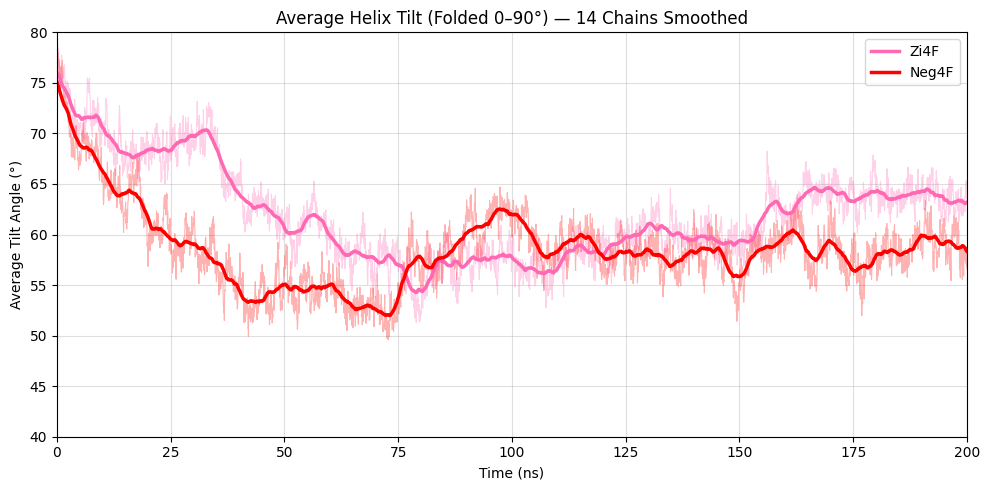


Zi4F  (75–200 ns): mean = 60.18°,  std = 3.26°
Neg4F (75–200 ns): mean = 58.60°,  std = 2.12°


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Paths ===
pos_dir  = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\analysis_pos\analysis_positive_200ns"
neg_dir  = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\analysis_neg\analysis_negative_200ns"
save_pdf = "zi4F_neg4F_angle_vs_time_smooth_fixed.pdf"
save_png = "zi4F_neg4F_angle_vs_time_smooth_fixed.png"


# ============================================================
#  load one XVG file with numpy
# ============================================================
def read_xvg(filepath):
    """
    Reads a GROMACS .xvg file.
    Skips comment lines (# or @).
    Returns a 2D numpy array: rows = frames, cols = [time, value1, value2, ...]
    """
    data = np.loadtxt(filepath, comments=["#", "@"])
    return data                                  # shape: (n_frames, n_columns)


# ============================================================
#  fold angles from 0–180° into 0–90°
# ============================================================
def fold_angle(angle):
    """
    If angle <= 90  → keep it
    If angle > 90   → return (180 - angle)
    """
    if angle <= 90:
        return angle
    else:
        return 180 - angle


# ============================================================
# Main loader: reads 14 chains, folds angles, averages
# ============================================================
def load_folded_avg(base_dir, name="system"):
    """
    Reads chain1_tilt_vsZ.xvg ... chain14_tilt_vsZ.xvg
    Folds each angle into 0–90°
    Returns a DataFrame with columns:
        time_ps, angle_chain1 ... angle_chain14, avg_tilt
    """

    all_dfs = []

    for chain in range(1, 15):                   # chains 1 to 14

        filepath = os.path.join(base_dir, f"chain{chain}_tilt_vsZ.xvg")

        # --- load with numpy (skips # and @ lines automatically) ---
        data    = read_xvg(filepath)             # shape: (n_frames, 2)
        time_ps = data[:, 0]                     # first column  = time
        angles  = data[:, 1]                     # second column = angle

        # --- fold each angle into 0–90° ---
        folded_list = []                         # empty list to collect results
        for a in angles:                         # loop over every angle value
            result = fold_angle(a)               # fold that single angle
            folded_list.append(result)           # add the result to the list

        folded_angles = np.array(folded_list)    # convert list → numpy array

        # --- store as a small DataFrame ---
        col_name = f"angle_chain{chain}"
        df = pd.DataFrame({
            "time_ps" : time_ps,
            col_name  : folded_angles
        })

        all_dfs.append(df)

    print(f"Loaded {len(all_dfs)} chains")       # prints once after all 14 are loaded


    # --- merge all 14 DataFrames on the time column ---
    merged_df = all_dfs[0]
    print("Merging chain 1...", '\n', merged_df.head(), '\n', )
    for df in all_dfs[1:]:
        merged_df = pd.merge(merged_df, df, on="time_ps", how="outer")


    # --- average across all 14 chains (one value per frame) ---
    merged_df["avg_tilt"] = merged_df.iloc[:, 1:].mean(axis=1)

    # --- save a CSV for inspection ---
    merged_df.to_csv(f"{name}_angle_merged.csv", index=False)

    return merged_df


# ============================================================
# Load both systems
# ============================================================
pos_df = load_folded_avg(pos_dir, name="zi4F")
neg_df = load_folded_avg(neg_dir, name="neg4F")

#print("Positive system:\n", pos_df.head())
print("Negative system:\n", neg_df.head())


# ============================================================
# Smooth with a rolling mean (~5 ns window)
# ============================================================
total_time_ns    = 200
n_frames         = len(pos_df)
smooth_window_ns = 5
window = int((smooth_window_ns / total_time_ns) * n_frames)

print(f"Smoothing window: {window} frames (~{smooth_window_ns} ns)")

pos_df["smooth_tilt"] = pos_df["avg_tilt"].rolling(window, center=True, min_periods=1).mean()
neg_df["smooth_tilt"] = neg_df["avg_tilt"].rolling(window, center=True, min_periods=1).mean()


# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 5))

# raw traces (faint)
plt.plot(pos_df["time_ps"] / 1000, pos_df["avg_tilt"],    color="#FF69B4", lw=0.8, alpha=0.3)
plt.plot(neg_df["time_ps"] / 1000, neg_df["avg_tilt"],    color="#ff0000", lw=0.8, alpha=0.3)

# smoothed traces (bold)
plt.plot(pos_df["time_ps"] / 1000, pos_df["smooth_tilt"], color="#FF69B4", lw=2.5, label="Zi4F")
plt.plot(neg_df["time_ps"] / 1000, neg_df["smooth_tilt"], color="#ff0000", lw=2.5, label="Neg4F")

plt.xlabel("Time (ns)")
plt.ylabel("Average Tilt Angle (°)")
plt.title("Average Helix Tilt (Folded 0–90°) — 14 Chains Smoothed")
plt.legend()
plt.ylim(40, 80)
plt.xlim(0, 200)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(save_pdf, dpi=300)
plt.savefig(save_png, dpi=400)
plt.show()


# ============================================================
# Statistics: 75–200 ns window
# ============================================================
pos_window = pos_df[(pos_df["time_ps"] >= 75000) & (pos_df["time_ps"] <= 200000)]
neg_window = neg_df[(neg_df["time_ps"] >= 75000) & (neg_df["time_ps"] <= 200000)]

print(f"\nZi4F  (75–200 ns): mean = {pos_window['avg_tilt'].mean():.2f}°,  std = {pos_window['avg_tilt'].std(ddof=1):.2f}°")
print(f"Neg4F (75–200 ns): mean = {neg_window['avg_tilt'].mean():.2f}°,  std = {neg_window['avg_tilt'].std(ddof=1):.2f}°")

# Pymol- show angle

# pymol - one chain

In [18]:
select chain14ca_395, resi 395 and name CA 
select chain14ca_413, resi 413 and name CA 

python
from pymol import cmd, cgo
import numpy as np

def angle_to_z_visual(sel1, sel2):

    # --- coordinates ---
    a = np.array(cmd.get_atom_coords(sel1))
    b = np.array(cmd.get_atom_coords(sel2))

    # --- vector ---
    v = b - a
    v_unit = v / np.linalg.norm(v)

    # --- z-axis ---
    z = np.array([0.0, 0.0, 1.0])

    # --- angle ---
    cos_theta = abs(np.dot(v_unit, z))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    angle = np.degrees(np.arccos(cos_theta))

    print("Tilt angle: %.2f degrees" % angle)

    # --- draw vector ---
    vec = [
        cgo.CYLINDER,
        a[0], a[1], a[2],
        b[0], b[1], b[2],
        0.2,
        1, 0, 0,
        1, 0, 0
    ]

    # --- draw z-axis ---
    z_len = np.linalg.norm(v)
    z_end = a + np.array([0.0, 0.0, z_len])

    z_axis = [
        cgo.CYLINDER,
        a[0], a[1], a[2],
        z_end[0], z_end[1], z_end[2],
        0.15,
        0, 0, 1,
        0, 0, 1
    ]

    # --- draw arc ---
    arc = []
    steps = 20
    for i in range(steps + 1):
        t = i / steps
        interp = (1 - t) * z + t * v_unit
        interp = interp / np.linalg.norm(interp)
        point = a + interp * (z_len * 0.5)
        arc.extend([cgo.VERTEX, point[0], point[1], point[2]])

    arc_obj = [cgo.BEGIN, cgo.LINE_STRIP, cgo.COLOR, 1, 1, 0] + arc + [cgo.END]

    # --- load objects ---
    cmd.load_cgo(vec, "vec")
    cmd.load_cgo(z_axis, "z_axis")
    cmd.load_cgo(arc_obj, "angle_arc")

    # --- label position (EDIT HERE 🔥) ---
    base_point = a + v_unit * (z_len * 0.6)

    # manual offset (you can change these!)
    offset = np.array([1.0, 1.0, 10.0])   # ← change this

    label_pos = base_point + offset

    cmd.pseudoatom("angle_label", pos=label_pos.tolist())

    label_text = "%.1f deg" % angle
    cmd.label("angle_label", '"' + label_text + '"')

    return angle

cmd.extend("angle_to_z_visual", angle_to_z_visual)

# run
angle_to_z_visual("chain14ca_395", "chain14ca_413")
python end

SyntaxError: invalid syntax (4209063394.py, line 1)

# pymol for all chains

In [ ]:
select chain1ca_2,   resi 2   and name CA 
select chain1ca_20,  resi 20  and name CA 

select chain2ca_41,  resi 41  and name CA 
select chain2ca_59,  resi 59  and name CA 

select chain3ca_61,  resi 61  and name CA 
select chain3ca_79,  resi 79  and name CA 

select chain4ca_100, resi 100 and name CA 
select chain4ca_118, resi 118 and name CA 

select chain5ca_120, resi 120 and name CA 
select chain5ca_138, resi 138 and name CA 

select chain6ca_159, resi 159 and name CA 
select chain6ca_177, resi 177 and name CA 

select chain7ca_179, resi 179 and name CA 
select chain7ca_197, resi 197 and name CA 

select chain8ca_218, resi 218 and name CA 
select chain8ca_236, resi 236 and name CA 

select chain9ca_238, resi 238 and name CA 
select chain9ca_256, resi 256 and name CA 

select chain10ca_277, resi 277 and name CA 
select chain10ca_295, resi 295 and name CA 

select chain11ca_297, resi 297 and name CA 
select chain11ca_315, resi 315 and name CA 

select chain12ca_336, resi 336 and name CA 
select chain12ca_354, resi 354 and name CA 

select chain13ca_356, resi 356 and name CA 
select chain13ca_374, resi 374 and name CA 

select chain14ca_395, resi 395 and name CA 
select chain14ca_413, resi 413 and name CA 
python 
from pymol import cmd, cgo
import numpy as np

def angle_to_z_visual(sel1, sel2, obj_name="chain", arc_scale=0.5, label_offset=(1.0, 1.0, 1.0)):
    # --- coordinates ---
    a = np.array(cmd.get_atom_coords(sel1))
    b = np.array(cmd.get_atom_coords(sel2))

    # --- vector from first CA to second CA ---
    v = b - a
    v_len = np.linalg.norm(v)
    if v_len == 0:
        print(f"{obj_name}: zero-length vector")
        return None

    v_unit = v / v_len

    # --- z-axis ---
    z = np.array([0.0, 0.0, 1.0])

    # --- angle with z-axis ---
    cos_theta = abs(np.dot(v_unit, z))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    angle = np.degrees(np.arccos(cos_theta))

    print(f"{obj_name}: tilt angle = {angle:.2f} degrees")

    # --- unique object names ---
    vec_name   = f"{obj_name}_vec"
    z_name     = f"{obj_name}_zaxis"
    arc_name   = f"{obj_name}_arc"
    label_name = f"{obj_name}_label"

    # delete old objects with same names if they exist
    cmd.delete(vec_name)
    cmd.delete(z_name)
    cmd.delete(arc_name)
    cmd.delete(label_name)

    # --- draw chain vector ---
    vec = [
        cgo.CYLINDER,
        a[0], a[1], a[2],
        b[0], b[1], b[2],
        0.2,
        1.0, 0.0, 0.0,
        1.0, 0.0, 0.0
    ]

    # --- draw local z-axis starting from point a ---
    z_end = a + np.array([0.0, 0.0, v_len])
    z_axis = [
        cgo.CYLINDER,
        a[0], a[1], a[2],
        z_end[0], z_end[1], z_end[2],
        0.15,
        0.0, 0.0, 1.0,
        0.0, 0.0, 1.0
    ]

    # --- draw arc between z-axis and vector ---
    arc = []
    steps = 40
    arc_radius = v_len * arc_scale

    for i in range(steps + 1):
        t = i / steps
        interp = (1 - t) * z + t * v_unit
        interp_len = np.linalg.norm(interp)
        if interp_len == 0:
            continue
        interp = interp / interp_len
        point = a + interp * arc_radius
        arc.extend([cgo.VERTEX, point[0], point[1], point[2]])

    arc_obj = [cgo.BEGIN, cgo.LINE_STRIP, cgo.COLOR, 1.0, 1.0, 0.0] + arc + [cgo.END]

    # --- load CGO objects ---
    cmd.load_cgo(vec, vec_name)
    cmd.load_cgo(z_axis, z_name)
    cmd.load_cgo(arc_obj, arc_name)

    # --- label ---
    mid_dir = (z + v_unit)
    mid_dir_len = np.linalg.norm(mid_dir)
    if mid_dir_len != 0:
        mid_dir = mid_dir / mid_dir_len
    else:
        mid_dir = v_unit

    label_pos = a + mid_dir * (arc_radius * 1.15) + np.array(label_offset)

    cmd.pseudoatom(label_name, pos=label_pos.tolist())
    cmd.label(label_name, f'"{angle:.1f} deg"')

    return angle


cmd.extend("angle_to_z_visual", angle_to_z_visual)

# ---- run for all chains ----
angle_to_z_visual("chain1ca_2",   "chain1ca_20",   "chain1")
angle_to_z_visual("chain2ca_41",  "chain2ca_59",   "chain2")
angle_to_z_visual("chain3ca_61",  "chain3ca_79",   "chain3")
angle_to_z_visual("chain4ca_100", "chain4ca_118",  "chain4")
angle_to_z_visual("chain5ca_120", "chain5ca_138",  "chain5")
angle_to_z_visual("chain6ca_159", "chain6ca_177",  "chain6")
angle_to_z_visual("chain7ca_179", "chain7ca_197",  "chain7")
angle_to_z_visual("chain8ca_218", "chain8ca_236",  "chain8")
angle_to_z_visual("chain9ca_238", "chain9ca_256",  "chain9")
angle_to_z_visual("chain10ca_277","chain10ca_295", "chain10")
angle_to_z_visual("chain11ca_297","chain11ca_315", "chain11")
angle_to_z_visual("chain12ca_336","chain12ca_354", "chain12")
angle_to_z_visual("chain13ca_356","chain13ca_374", "chain13")
angle_to_z_visual("chain14ca_395","chain14ca_413", "chain14")
python end

